In [6]:
pip install pandas numpy scikit-learn xgboost imbalanced-learn matplotlib seaborn

In [7]:
import zipfile

zip_path = "/content/archive (2).zip"

with zipfile.ZipFile(zip_path, "r") as z:
    print("Files inside ZIP:")
    for file in z.namelist():
        print(file)

Files inside ZIP:
creditcard.csv


In [8]:
import zipfile

zip_path = "/content/archive (2).zip"

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall("/content/")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [9]:
import pandas as pd

df = pd.read_csv("creditcard.csv")

print(df.shape)
print(df.head())
print(df['Class'].value_counts())

(284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V

In [10]:
X = df.drop('Class', axis=1)
y = df['Class']

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(y_train.value_counts())
print(y_test.value_counts())

Class
0    227451
1       394
Name: count, dtype: int64
Class
0    56864
1       98
Name: count, dtype: int64


In [12]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_sm.value_counts().to_dict())

Before SMOTE: {0: 227451, 1: 394}
After SMOTE: {0: 227451, 1: 227451}


In [13]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    eval_metric='logloss',
    random_state=42
)

model.fit(X_train_sm, y_train_sm)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [15]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]   # probability of fraud

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=4))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

[[56817    47]
 [   13    85]]
              precision    recall  f1-score   support

           0     0.9998    0.9992    0.9995     56864
           1     0.6439    0.8673    0.7391        98

    accuracy                         0.9989     56962
   macro avg     0.8219    0.9333    0.8693     56962
weighted avg     0.9992    0.9989    0.9990     56962

ROC-AUC: 0.9825916544164092


In [17]:
from sklearn.metrics import precision_recall_curve, f1_score
import numpy as np

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

# Compute F1 score at each threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("Best threshold:", best_threshold)
print("Best F1 score:", f1_scores[best_idx])

# Re-predict using this new threshold
y_pred_tuned = (y_proba >= best_threshold).astype(int)
print(classification_report(y_test, y_pred_tuned, digits=4))

Best threshold: 0.9361643
Best F1 score: 0.879581151782495
              precision    recall  f1-score   support

           0     0.9998    0.9998    0.9998     56864
           1     0.9032    0.8571    0.8796        98

    accuracy                         0.9996     56962
   macro avg     0.9515    0.9285    0.9397     56962
weighted avg     0.9996    0.9996    0.9996     56962



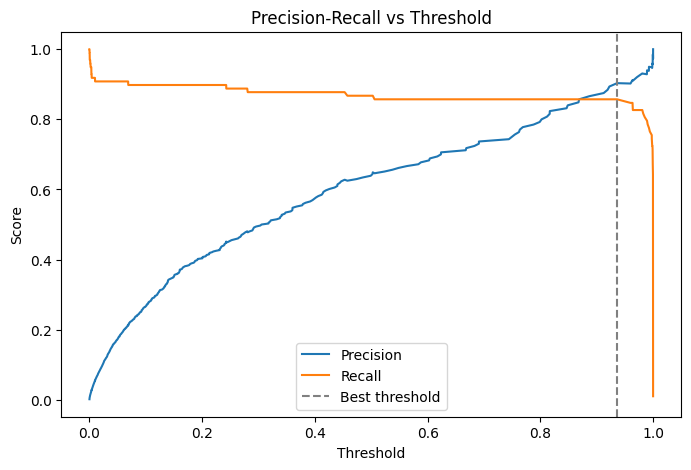

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold')
plt.axvline(best_threshold, color='gray', linestyle='--', label='Best threshold')
plt.legend()
plt.show()

<Figure size 800x1000 with 0 Axes>

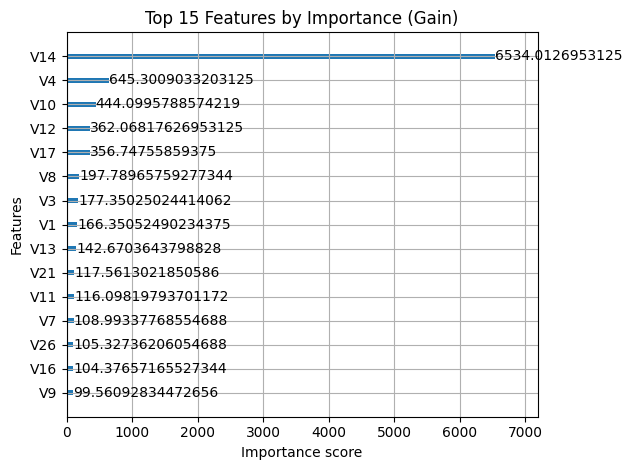

In [19]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 10))
plot_importance(model, max_num_features=15, importance_type='gain')
plt.title("Top 15 Features by Importance (Gain)")
plt.tight_layout()
plt.show()